In [228]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.inspection import permutation_importance
from scipy import stats
from sklearn.linear_model import LogisticRegression

%load_ext autoreload
%autoreload 2
from Datamodule import Datamodule
from Ensemble import Ensemble
from helpers import get_latest_run_dir

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
LABEL_NAMES = [
    "0.T-shirt",
    "1.Trouser",
    "2.Pullover",
    "3.Dress",
    "4.Coat",
    "5.Sandal",
    "6.Shirt",
    "7.Sneaker",
    "8.Bag",
    "9.Ankle boot",
]

In [7]:
datamodule = Datamodule()
datamodule.prepare_data()
datamodule.setup("test")

In [170]:
class SklearnWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, ensemble: Ensemble):
        self.ensemble = ensemble
        self.ensemble.eval()

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.ensemble.to(device)

    def fit(self, X, y):
        raise NotImplementedError()

    def _to_tensor(self, X) -> torch.Tensor:
        if not torch.is_tensor(X):
            X = torch.tensor(X)

        X = X.reshape(-1, 1, 28, 28)
        X = X.to(self.device)
        return X

    def predict(self, X):
        with torch.no_grad():
            X = self._to_tensor(X)
            return self.ensemble(X)

    def predict_proba(self, X):
        with torch.no_grad():
            X = self._to_tensor(X)
            return self.ensemble.predict_proba(X)

    @property
    def device(self):
        return next(self.ensemble.parameters()).device


In [171]:
latest_run_dir = get_latest_run_dir()
ensemble = SklearnWrapper(Ensemble(latest_run_dir))

['2026-06-24 13:26:58.782422', '2026-06-24 13:41:44.486169']
Latest run: 2026-06-24 13:41:44.486169
Latest run dir: checkpoints/run_2026-06-24 13:41:44.486169
Model for fold=0: checkpoints/run_2026-06-24 13:41:44.486169/fold0/model-epoch=14-val_loss=0.242.ckpt
Temperature for fold=0: 1.3736447095870972
Model for fold=1: checkpoints/run_2026-06-24 13:41:44.486169/fold1/model-epoch=11-val_loss=0.239.ckpt
Temperature for fold=1: 1.0928692817687988
Model for fold=2: checkpoints/run_2026-06-24 13:41:44.486169/fold2/model-epoch=10-val_loss=0.244.ckpt
Temperature for fold=2: 1.1840633153915405
Model for fold=3: checkpoints/run_2026-06-24 13:41:44.486169/fold3/model-epoch=14-val_loss=0.232.ckpt
Temperature for fold=3: 1.2276005744934082
Model for fold=4: checkpoints/run_2026-06-24 13:41:44.486169/fold4/model-epoch=10-val_loss=0.249.ckpt
Temperature for fold=4: 1.0976569652557373


In [176]:
accuracy = ensemble.score(datamodule.X_test, datamodule.y_test)
f"{accuracy=:.4f}"

'accuracy=0.9256'

In [191]:
pfi_all_class_importances = np.zeros((10, 28, 28))

for current_class in range(len(LABEL_NAMES)):
    this_class_indices = torch.where(datamodule.y_test == current_class)[0]
    X_xai, y_xai = datamodule.X_test[this_class_indices], datamodule.y_test[this_class_indices]

    r = permutation_importance(ensemble, X_xai.reshape(-1, 784), y_xai, n_repeats=10, random_state=0)

    data = []

    for feature_idx, importance in enumerate(r.importances_mean):
        feature_scores = r.importances[feature_idx]

        if np.all(feature_scores == feature_scores[0]):
            # If they are all identical and <= 0, it's definitely not important
            if feature_scores[0] <= 0:
                p_val = 1.0
            else:
                # If they are all identically positive (rare), it's highly important but t-test fails
                p_val = 0.0
        else:
            # Run the t-test only if there is variance in the scores
            t_stat, p_val = stats.ttest_1samp(feature_scores, popmean=0, alternative="greater")

        data.append({
            "importance": importance,
            "p-value": f"{p_val:.4f}",
        })

    df_importance = pd.DataFrame(data)
    pfi_pixels = df_importance["importance"].to_numpy().reshape(28, 28)
    pfi_all_class_importances[current_class] = pfi_pixels

In [193]:
importances_dir = Path("importances")
importances_dir.mkdir(exist_ok=True)

torch.save(torch.from_numpy(pfi_all_class_importances), importances_dir / "pfi_all_class_importances.pt")

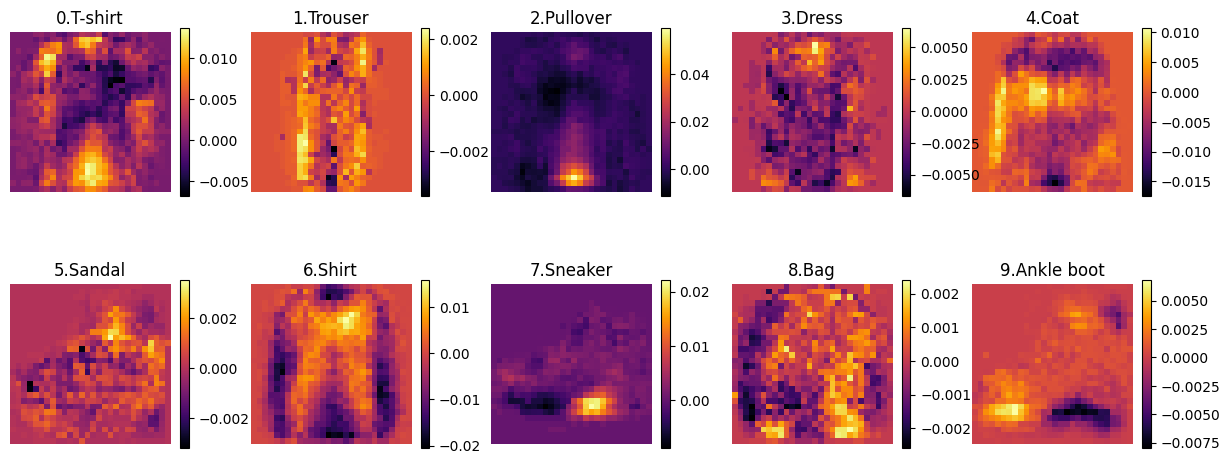

In [194]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()

for i in range(axs.size):
    ax = axs[i]
    pixels = pfi_all_class_importances[i]
    im = ax.imshow(pixels, cmap="inferno")
    ax.set_title(LABEL_NAMES[i])
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.show()

In [251]:
lime_all_class_importances = np.zeros((10, 28, 28))

pert_factor = 0.3
num_of_perturbations = 3000

for current_class in range(len(LABEL_NAMES)):
    params_stacked = []
    p_val_stacked = []

    this_class_indices = torch.where(datamodule.y_test == current_class)[0]
    stds = datamodule.X_test[this_class_indices].reshape(-1, 784).std(dim=0)
    stds = stds.unsqueeze(1)

    # Fewer cases for each class to reduce computation time
    n_cases = 100
    this_class_indices = this_class_indices[torch.randperm(this_class_indices.shape[0])[:n_cases]]
    X_xai, y_xai = datamodule.X_test[this_class_indices], datamodule.y_test[this_class_indices]
    X_xai = X_xai.reshape(-1, 784)

    for X_to_explain in X_xai:
        noise = torch.randn((X_to_explain.shape[0], num_of_perturbations)) * stds
        perturbations = X_to_explain.unsqueeze(1) + noise
        perturbations = perturbations.swapaxes(0, 1)
        distances = torch.exp(-torch.linalg.norm(perturbations - X_to_explain, dim=1))
        outputs = ensemble.predict(perturbations)
        y_surrogate = (outputs == current_class)

        perturbations = perturbations.detach().cpu().numpy()
        distances = distances.detach().cpu().numpy()
        y_surrogate = y_surrogate.detach().cpu().numpy().astype(int)

        if len(np.unique(y_surrogate)) < 2:
            # This sample was not affected by the perturbations
            params_stacked.append(np.zeros(784))
            continue

        clf = LogisticRegression(solver='liblinear', fit_intercept=False, C=1.0)
        clf.fit(perturbations, y_surrogate, sample_weight=distances)

        params_stacked.append(clf.coef_[0])

    lime_all_class_importances[current_class] = np.stack(params_stacked).mean(axis=0).reshape(28, 28)


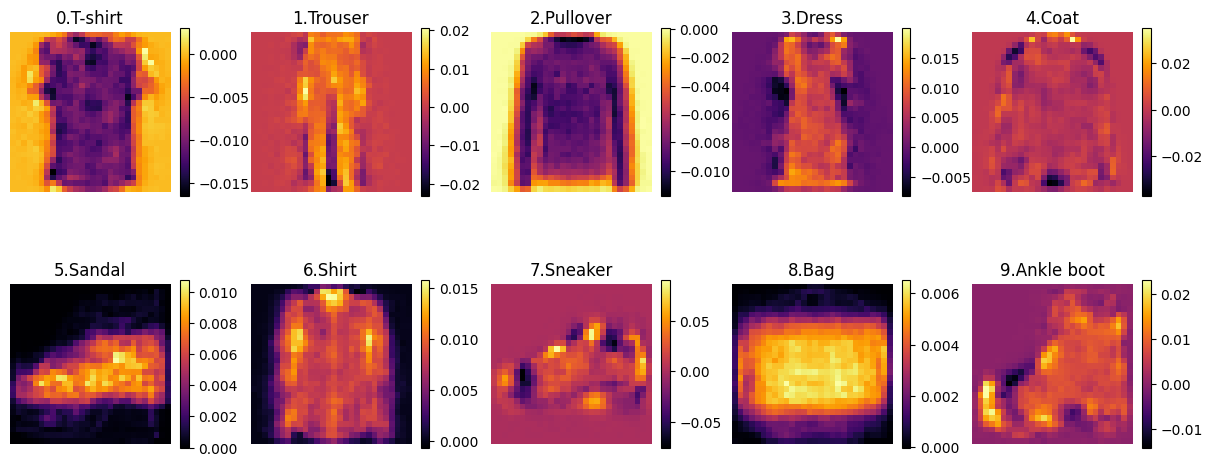

In [253]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()

for i in range(axs.size):
    ax = axs[i]
    pixels = lime_all_class_importances[i]
    im = ax.imshow(pixels, cmap="inferno")
    ax.set_title(LABEL_NAMES[i])
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.show()

In [254]:
importances_dir = Path("importances")
importances_dir.mkdir(exist_ok=True)

torch.save(torch.from_numpy(lime_all_class_importances), importances_dir / "lime_all_class_importances.pt")